In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline           #  스케일링 + 모델을 한번에 연결하는 파이프라인 기능을 위함
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier        # 여러 모델을 결합하는 Voting 앙상블 모델을 사용하기 위함

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# 2. iris 데이터 로드 및 학습데이터 분할

iris = load_iris()
X = iris.data  # x data
y= iris.target # y data
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [4]:
# 개별 모델 정의(SVM, KNN, RandomForest)

# SVM
svm_clf = make_pipeline(                       # make_pipeline : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
)

# KNN
knn_clf = make_pipeline(                       # make_pipeline : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# RandomForest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# 3개의 모델을 soft voting 방식으로 결합한 votingclassifier
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('rf', rf_clf)],
    voting = 'soft',                   # 각 모델의 예측 확률값을 평균내서 최종 예측을 만듬
    weights=[1,1,2]                     # 랜덤포레스트 예측 결과 비중을 높임
)


In [5]:
# 모델 학습(fit)

svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [6]:
# 모델 평가 및 정확도 출력
y_pred = voting_clf.predict(X_test)   # 테스트 데이터를 넣어 앙상블 모델로 예측 결과 출력
accuracy = accuracy_score(y_test, y_pred)

print("==voting classifier==")
print("accuracy : ", round(accuracy, 4))


==voting classifier==
accuracy :  0.9


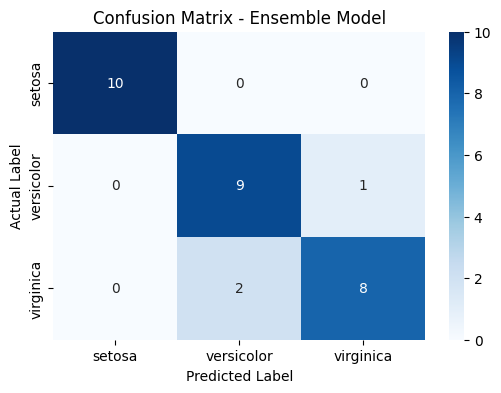

In [7]:
# confusion matrix 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Ensemble Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_2748\3046618392.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')


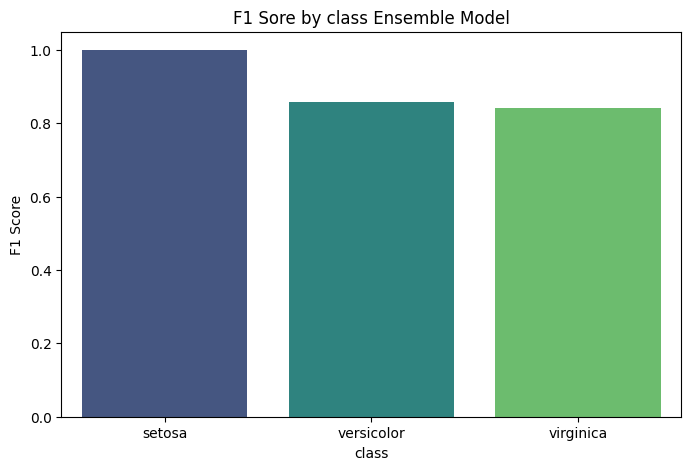

In [8]:
# classification
report = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True                   # dict 형태로 받아와서 dataframe 으로 시각화 출력
)

# class 별 f1-score만 리스트로 받아옴
f1_score= [report[c]['f1-score'] for c in class_names]

df_f1 = pd.DataFrame({'class' : class_names, 'f1': f1_score})

plt.figure(figsize=(8,5))
sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')

plt.title('F1 Sore by class Ensemble Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)    # 그래프에서 출력할 y 값의 범위 지정
plt.show()



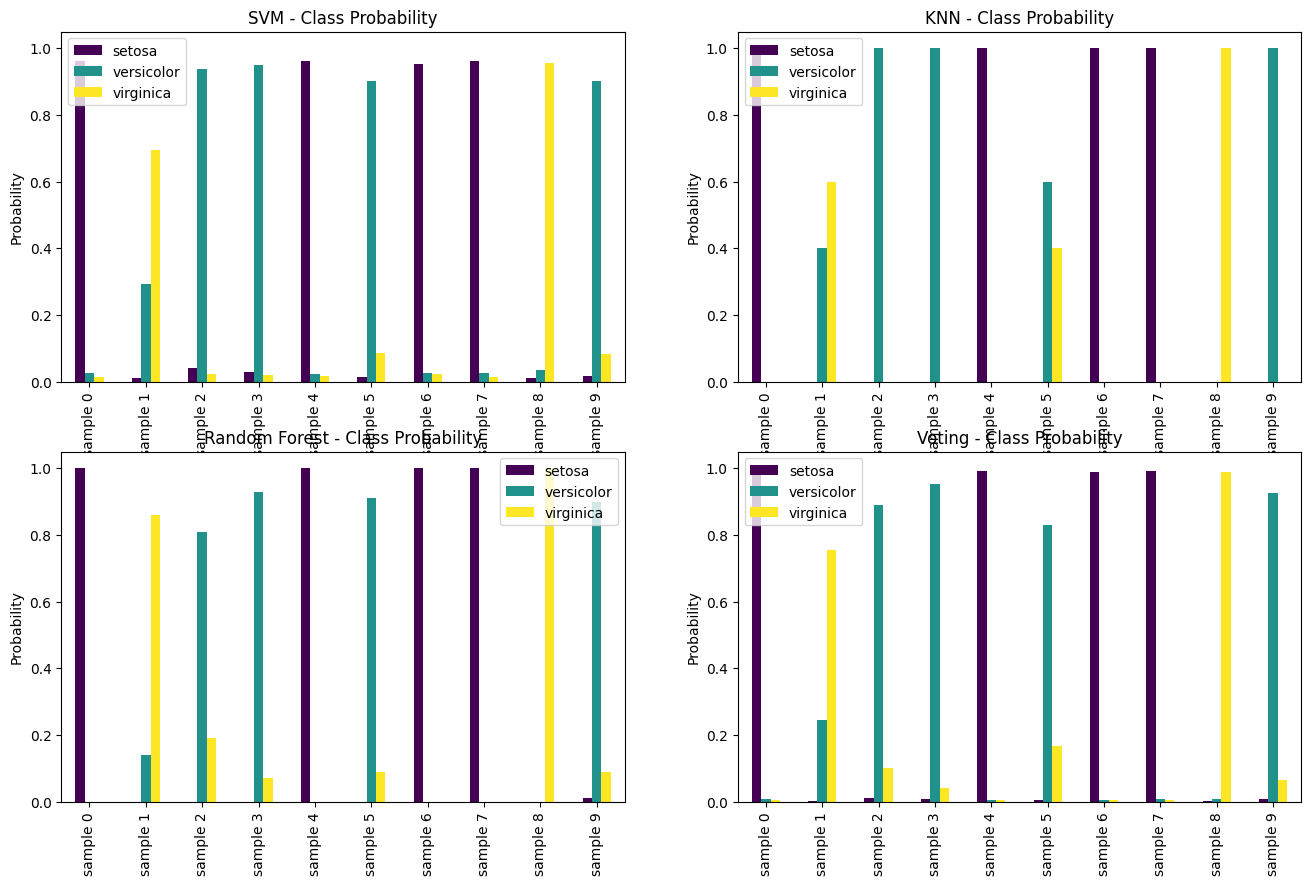

In [9]:
# 모델별 예측 확률 시각화
idx = np.arange(10)    # 10개 샘플 인덱스 생성
X_sample = X_test[idx]
y_sample = y_test[idx]

proba_svm = svm_clf.predict_proba(X_sample)   # svm의 예측 확률
proba_knn = knn_clf.predict_proba(X_sample)   # knn의 예측 확률
proba_rf = rf_clf.predict_proba(X_sample)   # rf의 예측 확률
proba_vote = voting_clf.predict_proba(X_sample)   # voting의 예측 확률

model_names = ["SVM", "KNN", "Random Forest", "Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize=(16,10))

for i, (model_name, proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2,2,i+1)
    df_prob = pd.DataFrame(proba, columns=class_names)
    df_prob.index = [f'sample {i}' for i in range(len(df_prob))]

    df_prob.plot(kind='bar', ax=plt.gca(), colormap='viridis')
    plt.ylabel('Probability')
    plt.ylim(0, 1.05)
    plt.title(f'{model_name} - Class Probability')
    plt.tight_layout

plt.show()